TEST KRR regression model first and analyse the features important 

In [1]:
# ===============================
# 0. IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, cross_validate
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
import joblib
import os

Coupling Distribution Plot

/var/folders/_n/_g0qz_kn5qg2mqn5q60r5q180000gn/T/ipykernel_40103/2534046150.py:95: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from current font.
  plt.tight_layout()
/var/folders/_n/_g0qz_kn5qg2mqn5q60r5q180000gn/T/ipykernel_40103/2534046150.py:95: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  plt.tight_layout()
/var/folders/_n/_g0qz_kn5qg2mqn5q60r5q180000gn/T/ipykernel_40103/2534046150.py:101: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from current font.
  plt.savefig(save_path, bbox_inches="tight")
/var/folders/_n/_g0qz_kn5qg2mqn5q60r5q180000gn/T/ipykernel_40103/2534046150.py:101: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  plt.savefig(save_path, bbox_inches="tight")


Slide visual successfully saved to: ../Results/coupling_scale_comparison.png


/Users/Roshan/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/Roshan/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


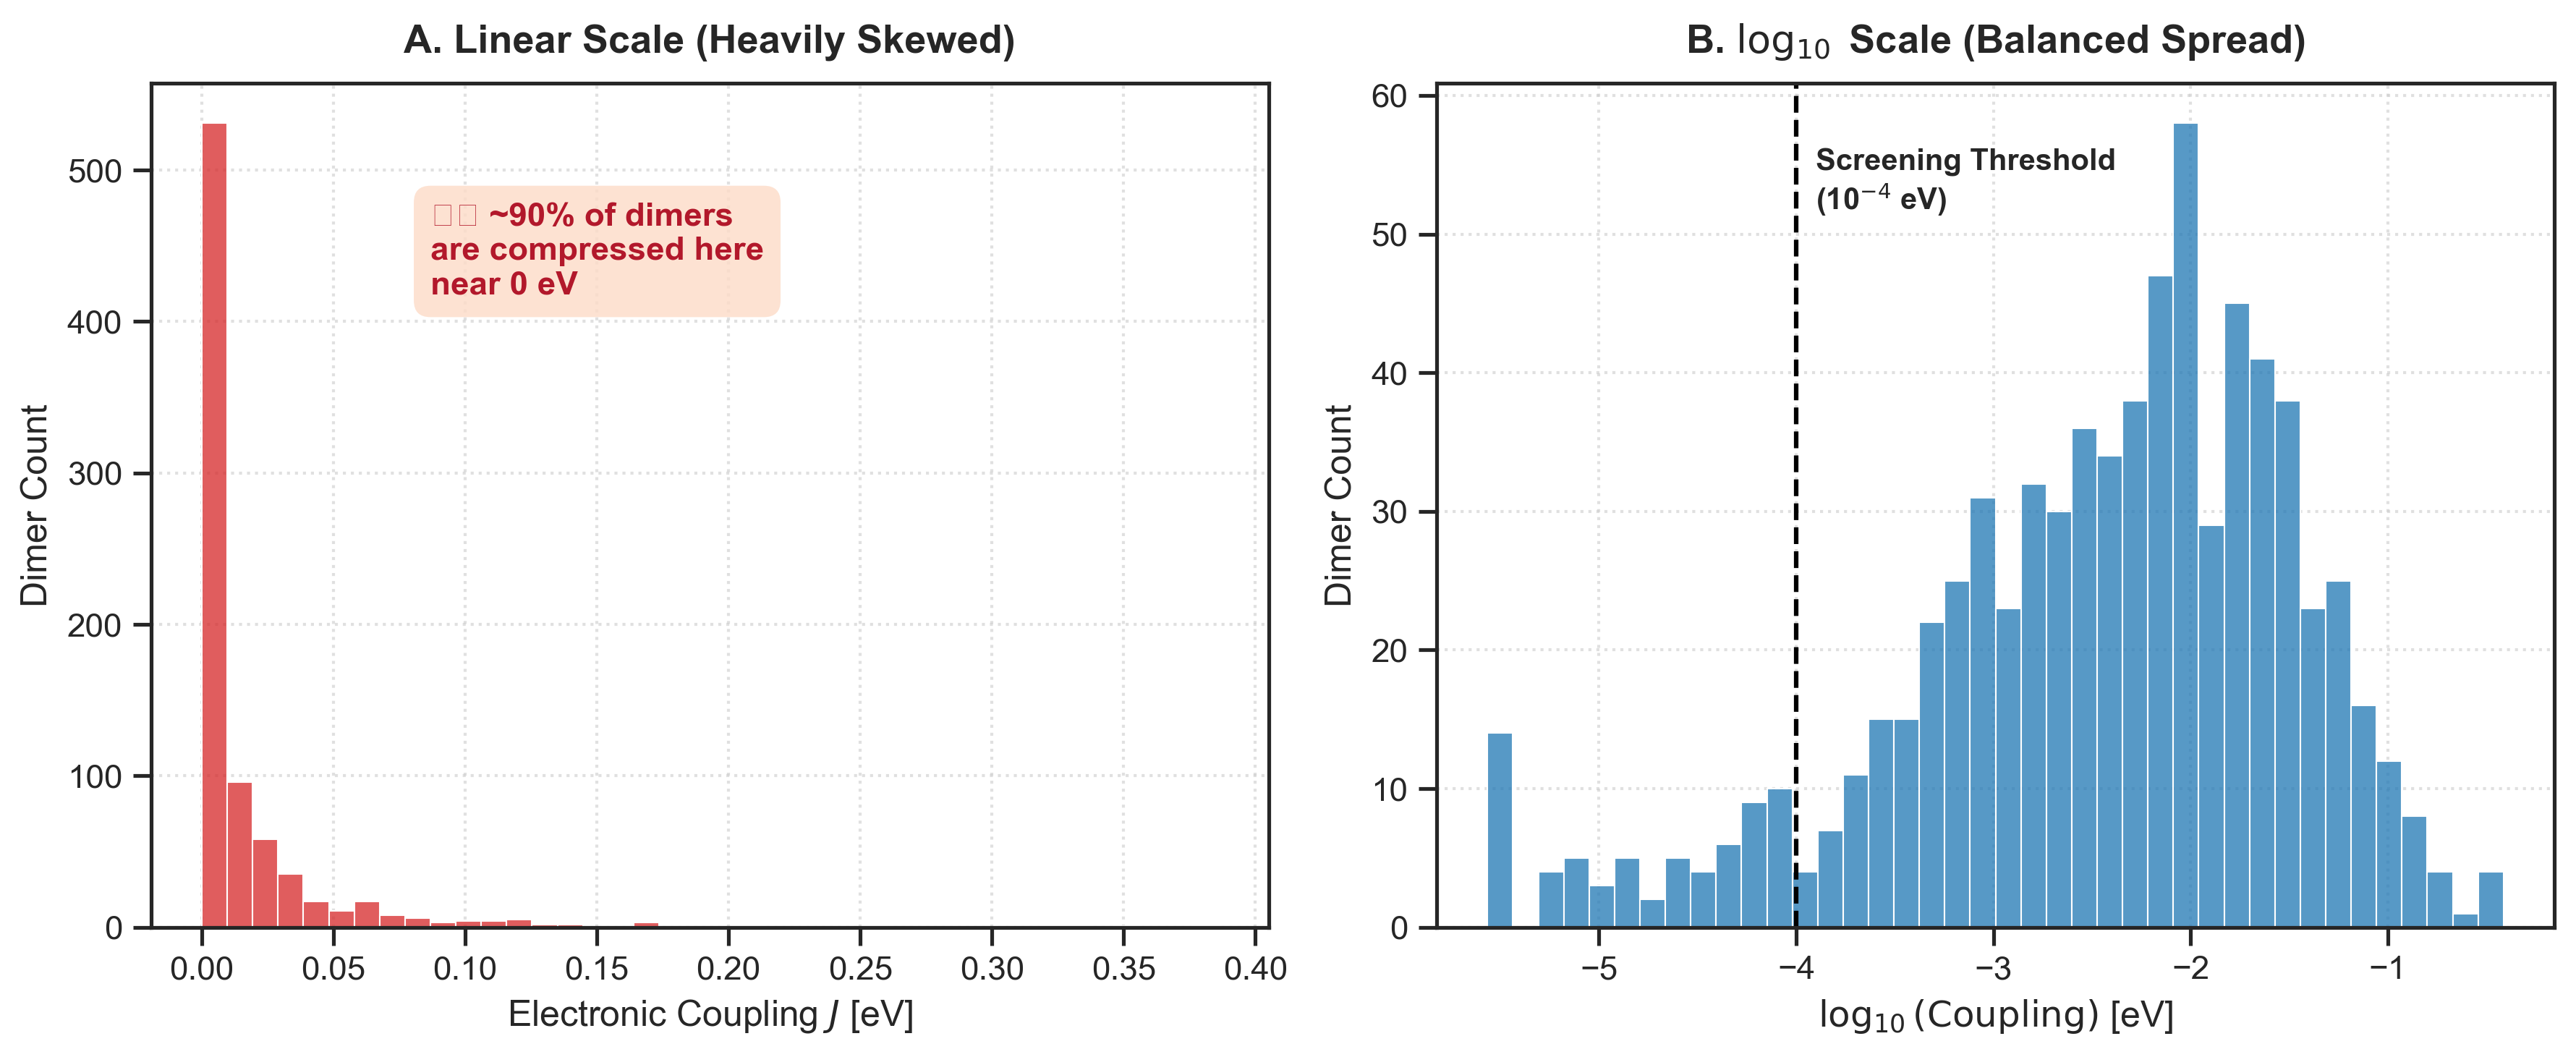

In [133]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. LOAD DATA
# =====================================================================
# Update this path if your file location changes
data_path = "../data/808_master_dataset_v2.csv"
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Could not find the dataset at: {data_path}")

df = pd.read_csv(data_path)

# Ensure both linear and log columns are prepared safely
# If 'Coupling_eV' isn't the exact name, change it to match your CSV column
if "Coupling_eV" not in df.columns and "log10_J_cdft" in df.columns:
    # Reconstruct linear coupling if only log is present
    df["Coupling_eV"] = 10 ** df["log10_J_cdft"]
elif "log10_J_cdft" not in df.columns and "Coupling_eV" in df.columns:
    alpha = 2e-6
    df["log10_J_cdft"] = np.log10(df["Coupling_eV"] + alpha)

# =====================================================================
# 2. PLOT CONFIGURATION (Side-by-Side for PPT)
# =====================================================================
sns.set_theme(style="ticks")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 11

# Create a wide figure perfect for a widescreen PPT slide (16:9 ratio)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

# ---------------------------------------------------------------------
# LEFT PLOT: Linear Scale Distribution (The Problem)
# ---------------------------------------------------------------------
sns.histplot(
    data=df,
    x="Coupling_eV",
    bins=40,
    color="#d62728",  # Crimson/Alert red to signify the skew problem
    alpha=0.75,
    edgecolor="w",
    linewidth=0.5,
    ax=ax1
)
ax1.set_title("A. Linear Scale (Heavily Skewed)", fontsize=13, fontweight="bold", pad=10)
ax1.set_xlabel("Electronic Coupling $J$ [eV]", fontsize=12)
ax1.set_ylabel("Dimer Count", fontsize=12)
ax1.grid(True, linestyle=":", alpha=0.6)

# Annotate the linear plot to show where most data hides
ax1.text(
    0.25, 0.75, 
    "⚠️ ~90% of dimers\nare compressed here\nnear 0 eV", 
    transform=ax1.transAxes, 
    color="#b2182b", 
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#fddbc7", edgecolor="none", alpha=0.8)
)

# ---------------------------------------------------------------------
# RIGHT PLOT: Log10 Scale Distribution (The Solution)
# ---------------------------------------------------------------------
sns.histplot(
    data=df,
    x="log10_J_cdft",
    bins=40,
    color="#1f77b4",  # Balanced blue to signify the solution
    alpha=0.75,
    edgecolor="w",
    linewidth=0.5,
    ax=ax2
)
ax1.set_ylabel("Dimer Count", fontsize=12)
ax2.set_title(r"B. $\log_{10}$ Scale (Balanced Spread)", fontsize=13, fontweight="bold", pad=10)
ax2.set_xlabel(r"$\log_{10}(\mathrm{Coupling})$ [eV]", fontsize=12)
ax2.set_ylabel("Dimer Count", fontsize=12)
ax2.grid(True, linestyle=":", alpha=0.6)

# Add a dashed line for your later threshold cut-off at -4 (1e-4 eV)
ax2.axvline(x=-4, color="black", linestyle="--", linewidth=1.5)
ax2.text(
    -3.9, ax2.get_ylim()[1] * 0.85, 
    "Screening Threshold\n(10$^{-4}$ eV)", 
    fontsize=10, 
    fontweight="bold"
)

# =====================================================================
# 3. SAVE AND SHOW
# =====================================================================
plt.tight_layout()

Results_dir = "../Results"
os.makedirs(Results_dir, exist_ok=True)
save_path = os.path.join(Results_dir, "coupling_scale_comparison.png")

plt.savefig(save_path, bbox_inches="tight")
print(f"Slide visual successfully saved to: {save_path}")
plt.show()

In [2]:
# ===============================
# 3. CREATE OUTPUT DIR
# ===============================
import os
Results_dir = "../Results"
os.makedirs(Results_dir, exist_ok=True)

KRR Analysis

In [ ]:
df = pd.read_csv("../data/808_alpha_shift_dataset.csv")

features = ["Min_HeavyDist_Ang",  "cos_theta",
            "cos_4phi", "cos_4psi", "FeFe_Dist_Ang"] #, "absS12"] # "d_lateral", "absS12",log_absS12","S12_sq", 

alpha = 2e-6  
# Apply the transformation
df["log10_Coupling"] = np.log10(df["Coupling_eV"] + alpha)
target = "log10_Coupling"

df = df.dropna(subset=features + [target])

print(f"Number of samples : {len(df)}")

X = df[features]
y = df[target]

#Startification for train/test split
df["coupling_bin"] = pd.qcut(
    df["log10_Coupling"],
    q=10,
    duplicates="drop"
)

#from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["coupling_bin"],
    random_state=42
)

X_train = train_df[features].values
#y_train = train_df["log10_J_cdft"].values
y_train = train_df[target].values
y_bins = train_df["coupling_bin"].cat.codes  # 🔑 reuse bins

X_test  = test_df[features].values
y_test  = test_df[target].values
""" Here train on high coupling and test on both (low+high) coupling states here
# =====================================================================
# 🟢 INSERT NEW SCRIPT HERE: Filter Training Set Only for High Coupling (> 1e-4)
# =====================================================================
# Calculate the log10 value for your 1e-4 threshold after the alpha shift
#Threshold = log10(1e-4 + 2e-6)
test_threshold = -5  # log10(1e-4) = -4, since alpha is negligible at this threshold

# Create a boolean mask for the training data rows that are above this threshold
#high_coupling_mask = y_train > train_threshold
high_coupling_mask = y_test > test_threshold
# Overwrite X_train and y_train with only the high coupling data
# X_train = X_train[high_coupling_mask]
# y_train = y_train[high_coupling_mask]
# y_bins = y_bins[high_coupling_mask] # Update bins if you use them in your CV splits
X_test = X_test[high_coupling_mask]
y_test = y_test[high_coupling_mask]
print(f"Filtered Training set size: {len(X_train)} samples")
print(f"Untouched Test set size: {len(X_test)} samples (includes all couplings)")
 Ends here"""

# 2️⃣ Prepare stratified splits manually
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_splits = list(skf.split(X_train, y_bins))  # now works correctly
# ===============================
# 3. CREATE OUTPUT DIR
# ===============================
Results_dir = "../Results"
os.makedirs(Results_dir, exist_ok=True)

# ===============================
# 4. KRR MODEL AND PARAMS
# ===============================
model_name = "Kernel Ridge"

# Pipeline with scaling + KRR
model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KernelRidge())
])

param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10],
    "model__gamma": [0.001, 0.01, 0.1, 1, 10],
    "model__kernel": ["rbf"]
}

# 4️⃣ Grid search with stratified CV
grid = GridSearchCV(
    model,
    param_grid,
    #cv = 5,
    cv=cv_splits,  # use the stratified splits
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)
KRR_best_model = grid.best_estimator_

print("Best parameters:", grid.best_params_)

results_list = []

# ===============================
# Cross-validation loop
# ===============================
for fold, (train_idx, val_idx) in enumerate(cv_splits):

    model = clone(KRR_best_model)
    model.fit(X_train[train_idx], y_train[train_idx])

    # Predictions
    y_pred_train = model.predict(X_train[train_idx])
    y_pred_val   = model.predict(X_train[val_idx])
    y_pred_test  = model.predict(X_test)

    # ===============================
    # Metrics
    # ===============================
    train_mae = mean_absolute_error(y_train[train_idx], y_pred_train)
    train_r2  = r2_score(y_train[train_idx], y_pred_train)

    val_mae   = mean_absolute_error(y_train[val_idx], y_pred_val)
    val_r2    = r2_score(y_train[val_idx], y_pred_val)

    test_mae  = mean_absolute_error(y_test, y_pred_test)
    test_r2   = r2_score(y_test, y_pred_test)

    # Print
    print(f"Fold {fold+1}:")
    print(f"  Train MAE = {train_mae:.5f}, R² = {train_r2:.5f}")
    print(f"  Val   MAE = {val_mae:.5f}, R² = {val_r2:.5f}")
    print(f"  Test  MAE = {test_mae:.5f}, R² = {test_r2:.5f}")

    # Store results
    results_list.append({
        "Fold": fold + 1,
        "Train_MAE": train_mae,
        "Train_R2": train_r2,
        "Val_MAE": val_mae,
        "Val_R2": val_r2,
        "Test_MAE": test_mae,
        "Test_R2": test_r2
    })

# ===============================
# Convert to DataFrame
# ===============================
results_df = pd.DataFrame(results_list)

# ===============================
# Compute Mean & Std
# ===============================
mean_row = {"Fold": "Mean"}
std_row  = {"Fold": "Std"}

for col in results_df.columns[1:]:
    mean_row[col] = results_df[col].mean()
    std_row[col]  = results_df[col].std()

results_df = pd.concat(
    [results_df, pd.DataFrame([mean_row, std_row])],
    ignore_index=True
)

# ===============================
# Save CSV
# ===============================
save_path = os.path.join(
    Results_dir,
    "808_krr_stratified_both_cv_5_feat_threshold_results.csv"
)

results_df.to_csv(save_path, index=False)

print(f"\nResults saved to: {save_path}")

# ===============================
# Pretty Print Summary
# ===============================
print("\n=== Model Performance Stratified CV (Mean ± Std) ===")

print(f"Train MAE = {mean_row['Train_MAE']:.5f} ± {std_row['Train_MAE']:.5f}")
print(f"Train R²  = {mean_row['Train_R2']:.5f} ± {std_row['Train_R2']:.5f}")

print(f"Val   MAE = {mean_row['Val_MAE']:.5f} ± {std_row['Val_MAE']:.5f}")
print(f"Val   R²  = {mean_row['Val_R2']:.5f} ± {std_row['Val_R2']:.5f}")

print(f"Test  MAE = {mean_row['Test_MAE']:.5f} ± {std_row['Test_MAE']:.5f}")
print(f"Test  R²  = {mean_row['Test_R2']:.5f} ± {std_row['Test_R2']:.5f}")

Number of samples : 808
Best parameters: {'model__alpha': 0.01, 'model__gamma': 0.1, 'model__kernel': 'rbf'}
Fold 1:
  Train MAE = 0.46264, R² = 0.72313
  Val   MAE = 0.61383, R² = 0.51865
  Test  MAE = 0.52976, R² = 0.60202
Fold 2:
  Train MAE = 0.46155, R² = 0.73564
  Val   MAE = 0.59077, R² = 0.56124
  Test  MAE = 0.55966, R² = 0.59047
Fold 3:
  Train MAE = 0.45161, R² = 0.73347
  Val   MAE = 0.62062, R² = 0.53498
  Test  MAE = 0.56323, R² = 0.58158
Fold 4:
  Train MAE = 0.45515, R² = 0.74640
  Val   MAE = 0.60601, R² = 0.48278
  Test  MAE = 0.57722, R² = 0.54975
Fold 5:
  Train MAE = 0.46329, R² = 0.73086
  Val   MAE = 0.56103, R² = 0.51718
  Test  MAE = 0.53772, R² = 0.60098

=== Model Performance Stratified CV (Mean ± Std) ===
Train MAE = 0.45885 ± 0.00518
Train R²  = 0.73390 ± 0.00843
Val   MAE = 0.59845 ± 0.02369
Val   R²  = 0.52297 ± 0.02862
Test  MAE = 0.55352 ± 0.01942
Test  R²  = 0.58496 ± 0.02138


In [ ]:
import os
import pickle
import pandas as pd
import numpy as np

# =====================================================================
# 1. LOAD THE ORIGINAL MAIN DATASET
# =====================================================================
main_df = pd.read_csv("../data/808_alpha_shift_dataset.csv")
filename_col = "Filename"

# =====================================================================
# 2. GENERATE PREDICTIONS FOR BOTH TRAIN AND TEST
# =====================================================================
y_pred_train = KRR_best_model.predict(X_train)
y_pred_test = KRR_best_model.predict(X_test)

y_train_true = y_train.flatten()
y_train_pred = y_pred_train.flatten()
y_test_true = y_test.flatten()
y_test_pred = y_pred_test.flatten()

# =====================================================================
# 3. HELPER FUNCTION TO FIND FILENAMES FOR NUMPY ARRAYS
# =====================================================================
def get_filenames_for_array(X_array, main_dataframe, feature_list, filename_column):
    """
    Matches rows of a NumPy array back to the original DataFrame 
    to retrieve the corresponding file names.
    """
    found_filenames = []
    # Extract just the relevant features from the main dataframe as a numpy array for fast matching
    main_features_matrix = main_dataframe[feature_list].values
    main_filenames = main_dataframe[filename_column].values
    
    for row in X_array:
        # Find where the row matches the main dataset features perfectly
        # (Using np.isclose to prevent minor floating-point precision mismatches)
        matches = np.all(np.isclose(main_features_matrix, row), axis=1)
        match_indices = np.where(matches)[0]
        
        if len(match_indices) > 0:
            found_filenames.append(main_filenames[match_indices[0]])
        else:
            found_filenames.append("Unknown_Geometry")
            
    return found_filenames

# Retrieve the true file names for both sets
print("Mapping NumPy arrays back to original file names...")
train_filenames = get_filenames_for_array(X_train, main_df, features, filename_col)
test_filenames = get_filenames_for_array(X_test, main_df, features, filename_col)

# =====================================================================
# 4. GENERATE THE DETAILED TRAIN AND TEST CSV FILES
# =====================================================================
Results_dir = "../Results"
csv_dir = os.path.join(Results_dir, "data_csv")
os.makedirs(csv_dir, exist_ok=True)

# --- Create Detailed Training CSV ---
train_analysis_df = pd.DataFrame({
    "Actual_File_Name": train_filenames,
    "True_Coupling_log10": y_train_true,
    "Predicted_Coupling_log10": y_train_pred,
    "Predicted_True_Ratio_Linear": 10 ** (y_train_pred - y_train_true)
})
# Populating the feature values directly from the X_train numpy columns
for i, feat in enumerate(features):
    train_analysis_df[feat] = X_train[:, i]

###To save the training analysis
# SORTING STEP: Sorts by the ratio column in increasing order
test_analysis_df = train_analysis_df.sort_values(by="Predicted_True_Ratio_Linear", ascending=True)

# Save the sorted DataFrame to disk
test_csv_path = os.path.join(csv_dir, "krr_5feat_808_train_analysis.csv")
test_analysis_df.to_csv(test_csv_path, index=False)

print(f"Detailed Test analysis (Sorted by Ratio) saved to: {test_csv_path}")
test_filenames = get_filenames_for_array(X_test, main_df, features, filename_col)

test_analysis_df = pd.DataFrame({
    "Actual_File_Name": test_filenames,
    "True_Coupling_log10": y_test_true,
    "Predicted_Coupling_log10": y_test_pred,
    "Predicted_True_Ratio_Linear": 10 ** (y_test_pred - y_test_true)
})

# Populating the feature values directly from the X_test numpy columns
for i, feat in enumerate(features):
    test_analysis_df[feat] = X_test[:, i]

# SORTING STEP: Sorts by the ratio column in increasing order
test_analysis_df = test_analysis_df.sort_values(by="Predicted_True_Ratio_Linear", ascending=True)

# Save the sorted DataFrame to disk
test_csv_path = os.path.join(csv_dir, "krr_5feat_808_test_analysis.csv")
test_analysis_df.to_csv(test_csv_path, index=False)

print(f"Detailed Test analysis (Sorted by Ratio) saved to: {test_csv_path}")

# =====================================================================
# 5. PACKAGE EVERYTHING INTO THE PICKLE FILE (UNCHANGED)
# =====================================================================
plot_data = {
    "model_name": "Kernel Ridge Regression",
    "best_params": grid.best_params_,
    "features": features,
    "X_train": X_train,
    "y_train_true": y_train_true,
    "y_train_pred": y_train_pred,
    "X_test": X_test,
    "y_true": y_test_true,
    "y_pred": y_test_pred,
    "best_model": KRR_best_model
}

pkl_save_path = os.path.join(Results_dir, "1_krr_5feat_808_data.pkl")
with open(pkl_save_path, "wb") as f:
    pickle.dump(plot_data, f)

print(f"Success! Analysis CSVs generated.")
print(f"Train path: {train_csv_path}")
print(f"Test path: {test_csv_path}")

Mapping NumPy arrays back to original file names...
Detailed Test analysis (Sorted by Ratio) saved to: ../Results/data_csv/krr_5feat_808_train_analysis.csv
Detailed Test analysis (Sorted by Ratio) saved to: ../Results/data_csv/krr_5feat_808_test_analysis.csv
Success! Analysis CSVs generated.
Train path: ../Results/data_csv/krr_6feat_674_train_analysis.csv
Test path: ../Results/data_csv/krr_5feat_808_test_analysis.csv


To save the PKl results

In [ ]:
import pickle

# ===============================
# SAVE MODEL & DATA FOR PARITY PLOT
# ===============================
# Ensure Results_dir is defined (matching commented path)
Results_dir = "../Results" 
os.makedirs(Results_dir, exist_ok=True)

# 1. Generate final predictions using  best KRR model on the test set
y_pred_test_final = KRR_best_model.predict(X_test)

# 2. Package everything you need for the parity plot into a single dictionary
plot_data = {
    "model_name": "Kernel Ridge Regression",
    "best_params": grid.best_params_,
    "features": features,
    "X_test": X_test,
    "y_true": y_test,
    "y_pred": y_pred_test_final,
    "best_model": KRR_best_model  # Saves the actual trained pipeline (scaler + model)
}

# 3. Define the pickle save path
pkl_save_path = os.path.join(
    Results_dir,
    "krr_5feat_808_data.pkl"
)

# 4. Write to disk
with open(pkl_save_path, "wb") as f:
    pickle.dump(plot_data, f)

print(f"Parity plot data and trained model successfully saved to: {pkl_save_path}")

Parity plot data and trained model successfully saved to: ../Results/krr_5feat_808_data.pkl


To save true and predicted coupling from .pkl

In [ ]:
import os
import pickle
import pandas as pd

# =====================================================================
# 1. SETUP PATHS AND LOAD DATA
# =====================================================================
Results_dir = "../Results"
pkl_save_path = os.path.join(Results_dir, "krr_6feat_674_data.pkl")

if not os.path.exists(pkl_save_path):
    raise FileNotFoundError(f"Could not find the pickle file at: {pkl_save_path}")

with open(pkl_save_path, "rb") as f:
    saved_data = pickle.load(f)

# =====================================================================
# 2. EXTRACT AND SAVE TRUE & PREDICTED VALUES TO CSV
# =====================================================================
print("Extracting data from pickle and saving to CSV...")

# Create the specific sub-folder for CSV data if it doesn't exist
csv_dir = os.path.join(Results_dir, "data_csv")
os.makedirs(csv_dir, exist_ok=True)

# Pull the arrays directly from your saved pickle dictionary keys
# (.flatten() ensures they align cleanly as 1D columns)
csv_data = pd.DataFrame({
    "True_Coupling_log10": saved_data["y_true"].flatten(),
    "Predicted_Coupling_log10": saved_data["y_pred"].flatten()
})

# Define the final CSV destination path
csv_save_path = os.path.join(csv_dir, "krr_6feat_674_predictions.csv")

# Write the data to a clean CSV file
csv_data.to_csv(csv_save_path, index=False)

print(f"Data successfully extracted and saved to CSV at: {csv_save_path}")

Extracting data from pickle and saving to CSV...
Data successfully extracted and saved to CSV at: ../Results/data_csv/krr_6feat_674_predictions.csv


Parity plot

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score

# =====================================================================
# 1. SETUP PATHS AND LOAD DATA
# =====================================================================
Results_dir = "../Results"
pkl_save_path = os.path.join(Results_dir, "krr_5feat_808_data.pkl")

if not os.path.exists(pkl_save_path):
    raise FileNotFoundError(f"Could not find the pickle file at: {pkl_save_path}")

with open(pkl_save_path, "rb") as f:
    saved_data = pickle.load(f)

# Extract variables from your saved dictionary
best_model = saved_data["best_model"]
X_test = saved_data["X_test"]
y_test_true = saved_data["y_true"]

y_test_pred = best_model.predict(X_test)

# Calculate final test metrics for the plot legend/text box
test_mae = mean_absolute_error(y_test_true, y_test_pred)
test_r2 = r2_score(y_test_true, y_test_pred)

# =====================================================================
# 2. PLOT CONFIGURATION (Publication Quality)
# =====================================================================
sns.set_theme(style="ticks")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 12

fig, ax = plt.subplots(figsize=(6, 5.5), dpi=300)

# Scatter plot for Test Data
ax.scatter(
    y_test_true, 
    y_test_pred, 
    c="#1f77b4",          # Professional blue
    alpha=0.7, 
    edgecolors="w", 
    linewidths=0.5, 
    s=50, 
    label=f"Test Set (N={len(y_test_true)})"
)

# =====================================================================
# 3. ADD THE AXIS limits AND PERFECT PARITY LINE (Y = X)
# =====================================================================
# Dynamically determine limits based on data range
min_val = min(y_test_true.min(), y_test_pred.min()) - 0.3
max_val = max(y_test_true.max(), y_test_pred.max()) + 0.3

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

# Ideal 45-degree parity line
ax.plot(
    [min_val, max_val], [min_val, max_val], 
    color="#d62728",     # Muted red line
    linestyle="--", 
    linewidth=1.5, 
    label="Perfect Prediction"
)

# =====================================================================
# 4. LABELS, LEGEND, AND METRICS TEXT BOX
# =====================================================================
ax.set_xlabel(r"True $\log_{10}(\mathrm{Coupling} + \alpha)$ [eV]", fontsize=13, fontweight="bold")
ax.set_ylabel(r"Predicted $\log_{10}(\mathrm{Coupling} + \alpha)$ [eV]", fontsize=13, fontweight="bold")
ax.set_title("Kernel Ridge Regression: Electronic Coupling Parity 808 5 feature", fontsize=14, fontweight="bold", pad=15)

# Metrics text box overlay
stats_text = f"Test MAE: {test_mae:.3f}\nTest $R^2$: {test_r2:.3f}"
bbox_props = dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.85)
ax.text(
    0.05, 0.95, 
    stats_text, 
    transform=ax.transAxes, 
    fontsize=11,
    verticalalignment="top", 
    bbox=bbox_props
)

# Grid and Legend layout
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="lower right", frameon=True, facecolor="white", edgecolor="none")

# Clean up layout margins
plt.tight_layout()

# =====================================================================
# 5. SAVE GRAPH
# =====================================================================
plot_save_path = os.path.join(Results_dir, "krr_coupling_5feat_808_parity_plot.png")
plt.savefig(plot_save_path, bbox_inches="tight")
plt.close()

print(f"Parity plot successfully generated and saved to: {plot_save_path}")

Parity plot successfully generated and saved to: ../Results/krr_coupling_5feat_808_parity_plot.png


To plot side by side for value distribuiton and residual distribution plot

In [ ]:
# =====================================================================
# 6. SIDE-BY-SIDE DISTRIBUTION PLOTS
# =====================================================================
print("Generating side-by-side distribution plots...")

# Create a figure with 1 row and 2 columns
fig_dist, axs = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

# ---------------------------------------------------------------------
# Plot 1 (Left): True vs. Predicted Overlap
# ---------------------------------------------------------------------
sns.histplot(
    y_test_true,
    kde=True,
    stat="density",
    color="#1f77b4",          # True data blue
    alpha=0.3,
    linewidth=1.5,
    label="True Values",
    ax=axs[0]
)

sns.histplot(
    y_test_pred,
    kde=True,
    stat="density",
    color="#ff7f0e",          # Predicted data orange
    alpha=0.3,
    linewidth=1.5,
    label="Predicted Values",
    ax=axs[0]
)

axs[0].set_xlabel(r"$\log_{10}(\mathrm{Coupling} + \alpha)$ [eV]", fontsize=12, fontweight="bold")
axs[0].set_ylabel("Probability Density", fontsize=12, fontweight="bold")
axs[0].set_title("(a) Value Distributions", fontsize=13, fontweight="bold", pad=10)
axs[0].grid(True, linestyle=":", alpha=0.6)
axs[0].legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none", fontsize=10)

# ---------------------------------------------------------------------
# Plot 2 (Right): Residuals Distribution (Errors)
# ---------------------------------------------------------------------
residuals = y_test_true - y_test_pred

sns.histplot(
    residuals,
    kde=True,
    stat="density",
    color="#2ca02c",          # Professional green for errors
    alpha=0.4,
    linewidth=1.5,
    ax=axs[1]
)

# Add a vertical line at 0 to show ideal error center
axs[1].axvline(0, color="#d62728", linestyle="--", linewidth=1.5, label="Zero Error")

axs[1].set_xlabel(r"Residual Error [$\Delta\log_{10}(\mathrm{Coupling})$]", fontsize=12, fontweight="bold")
axs[1].set_ylabel("Probability Density", fontsize=12, fontweight="bold")
axs[1].set_title("(b) Residuals Distribution 5 feat 808", fontsize=13, fontweight="bold", pad=10)
axs[1].grid(True, linestyle=":", alpha=0.6)
axs[1].legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none", fontsize=10)

# Make lines thicker for presentation visibility
for ax in axs:
    for line in ax.lines:
        line.set_linewidth(2.5)

# Clean up structural layout margins
plt.tight_layout()

# =====================================================================
# 7. SAVE SIDE-BY-SIDE GRAPH
# =====================================================================
side_by_side_save_path = os.path.join(Results_dir, "krr_coupling_5feat_808_side_distribution_plots.png")
plt.savefig(side_by_side_save_path, bbox_inches="tight")
plt.close()

print(f"Side-by-side distribution plots successfully saved to: {side_by_side_save_path}")

Filtered value distribution and residual distribution plot

In [29]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score

# =====================================================================
# 1. SETUP PATHS AND LOAD DATA
# =====================================================================
Results_dir = "../Results"
pkl_save_path = os.path.join(Results_dir, "krr_6feat_674_data.pkl")

if not os.path.exists(pkl_save_path):
    raise FileNotFoundError(f"Could not find the pickle file at: {pkl_save_path}")

with open(pkl_save_path, "rb") as f:
    saved_data = pickle.load(f)

# Extract variables from your saved dictionary
best_model = saved_data["best_model"]
X_test = saved_data["X_test"]
y_test_true = saved_data["y_true"]
y_test_pred = saved_data["y_pred"]

# =====================================================================
# 9. TWO-PANEL PLOT: VALUES & RESIDUALS FOR LOW-COUPLING REGIME (< -3.4)
# =====================================================================
print("Generating value and residual plots strictly for the low-coupling regime...")

# Create a 1-row, 2-column subplot figure layout
fig, (ax_val, ax_res) = plt.subplots(1, 2, figsize=(13, 5), dpi=300)

# Apply the strict low-coupling filter to the test set
filter_mask = y_test_true > -3.4
y_test_true_filtered = y_test_true[filter_mask].flatten()
y_test_pred_filtered = y_test_pred[filter_mask].flatten()

if len(y_test_true_filtered) > 0:
    # ---------------------------------------------------------------------
    # PANEL 1: Filtered Value Distribution (True < -3.4)
    # ---------------------------------------------------------------------
    # Plot True Values matching the condition
    sns.histplot(
        y_test_true_filtered,
        kde=True,
        stat="density",
        color="#1f77b4",          # Professional blue
        alpha=0.3,
        linewidth=1.5,
        label=f"True Values (N={len(y_test_true_filtered)})",
        ax=ax_val
    )

    # Plot what the model predicted for those exact same configurations
    sns.histplot(
        y_test_pred_filtered,
        kde=True,
        stat="density",
        color="#ff7f0e",          # Professional orange
        alpha=0.3,
        linewidth=1.5,
        label="Predictions",
        ax=ax_val
    )
    
    ax_val.set_title("High-Coupling Values 6feat (True > -3.4)", fontsize=12, fontweight="bold")
    ax_val.set_xlabel(r"$\log_{10}(\mathrm{Coupling} + \alpha)$ [eV]", fontsize=11, fontweight="bold")
    ax_val.set_ylabel("Probability Density", fontsize=11, fontweight="bold")
    ax_val.grid(True, linestyle=":", alpha=0.6)
    ax_val.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none", fontsize=10)

    # ---------------------------------------------------------------------
    # PANEL 2: Filtered Residual Distribution (True < -3.4)
    # ---------------------------------------------------------------------
    # Calculate residuals ONLY for this low-coupling group
    residuals_filtered = y_test_true_filtered - y_test_pred_filtered

    # Calculate local error statistics for this specific region
    rmse_filtered = np.sqrt(np.mean(residuals_filtered**2))
    mae_filtered = np.mean(np.abs(residuals_filtered))

    # Plot the histogram of filtered errors
    sns.histplot(
        residuals_filtered,
        kde=True,
        stat="density",
        color="#2ca02c",          # Distinct professional green for residuals
        alpha=0.3,
        linewidth=1.5,
        label=f"High-Coupling Region",
        ax=ax_res
    )

    # Draw a dashed red vertical line at exactly Zero Residual (Perfect Prediction)
    ax_res.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Zero Error Baseline")

    # Axis configurations
    ax_res.set_title("high-Coupling Residual Distribution", fontsize=12, fontweight="bold")
    ax_res.set_xlabel(r"Local Residual $[\log_{10}(\mathrm{True}) - \log_{10}(\mathrm{Pred})]$", fontsize=11, fontweight="bold")
    ax_res.set_ylabel("Probability Density", fontsize=11, fontweight="bold")
    ax_res.grid(True, linestyle=":", alpha=0.6)

    # Overlay performance metrics for the low-coupling subset in a text box
    stats_text = f"Local RMSE: {rmse_filtered:.3f}\nLocal MAE:  {mae_filtered:.3f}"
    ax_res.text(
        0.05, 0.82, stats_text, 
        transform=ax_res.transAxes, 
        fontsize=10, 
        fontweight="bold",
        verticalalignment='top', 
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='none')
)
    ax_res.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none", fontsize=10)

else:
    # Fallback text if the mask returns 0 rows
    for ax in [ax_val, ax_res]:
        ax.text(0.5, 0.5, "No data found for True > -3.4", ha='center', va='center', transform=ax.transAxes)

# ---------------------------------------------------------------------
# CLEAN UP AND BOX FINISHING
# ---------------------------------------------------------------------
# Make line weights uniform across both KDE plots
for ax in [ax_val, ax_res]:
    for line in ax.lines:
        line.set_linewidth(2.5)

plt.suptitle("Low-Coupling Regime Diagnostic 6 feat (True Calculations > -3.4)", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()

# Save filtered subplots
joint_save_path = os.path.join(Results_dir, "krr_6feat_674_high_coupling_diagnostics.png")
plt.savefig(joint_save_path, bbox_inches="tight")
plt.close()

print(f"Isolated diagnostic plots successfully saved to: {joint_save_path}")

Generating value and residual plots strictly for the low-coupling regime...
Isolated diagnostic plots successfully saved to: ../Results/krr_6feat_674_high_coupling_diagnostics.png


Filtered distribution plot for small true coupling data

In [10]:
# =====================================================================
# 9. FILTERED DISTRIBUTION PLOT (True Values < -3.4)
# =====================================================================
print("Generating filtered distribution plot for true values < -3.4...")

# Create a boolean mask to filter data where True Values are strictly less than -3.4
filter_mask = y_test_true < -3.4

# Apply the mask to both true and predicted arrays
y_test_true_filtered = y_test_true[filter_mask]
y_test_pred_filtered = y_test_pred[filter_mask]

# Create a new figure for the filtered distribution
fig_filt, ax_filt = plt.subplots(figsize=(6.5, 5), dpi=300)

if len(y_test_true_filtered) > 0:
    # Plot True Values matching the condition
    sns.histplot(
        y_test_true_filtered,
        kde=True,
        stat="density",
        color="#1f77b4",          # Professional blue
        alpha=0.3,
        linewidth=1.5,
        label=f"True Values (N={len(y_test_true_filtered)})",
        ax=ax_filt
    )

    # Plot what the model predicted for those exact same configurations
    sns.histplot(
        y_test_pred_filtered,
        kde=True,
        stat="density",
        color="#ff7f0e",          # Professional orange
        alpha=0.3,
        linewidth=1.5,
        label="Corresponding Predictions",
        ax=ax_filt
    )

    # Make the lines crisp and visible
    for line in ax_filt.lines:
        line.set_linewidth(2.5)

    # Labels and Styling
    ax_filt.set_xlabel(r"$\log_{10}(\mathrm{Coupling} + \alpha)$ [eV]", fontsize=13, fontweight="bold")
    ax_filt.set_ylabel("Probability Density", fontsize=13, fontweight="bold")
    ax_filt.set_title("Distribution Analysis (Filtered True < -3.4)", fontsize=14, fontweight="bold", pad=15)
    
    ax_filt.grid(True, linestyle=":", alpha=0.6)
    ax_filt.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none", fontsize=11)
    
    plt.tight_layout()

    # Save Filtered Graph
    filt_save_path = os.path.join(Results_dir, "krr_coupling_6feat_674_filtered_lessthan_3.4_plot.png")
    plt.savefig(filt_save_path, bbox_inches="tight")
    plt.close()
    
    print(f"Filtered distribution plot successfully saved to: {filt_save_path}")
else:
    plt.close()
    print("Warning: No data points found with true coupling values greater than -3.4.")

Generating filtered distribution plot for true values < -3.4...
Filtered distribution plot successfully saved to: ../Results/krr_coupling_6feat_674_filtered_lessthan_3.4_plot.png


Predict new dimer using saved .pkl 

In [ ]:
import pickle
import numpy as np
import pandas as pd

# 1. Load the saved dictionary
pkl_path = "../Results/krr_parity_plot_data.pkl"
with open(pkl_path, "rb") as f:
    saved_data = pickle.load(f)

# Extract the trained pipeline and the feature names
model_pipeline = saved_data["best_model"]
feature_names = saved_data["features"]

print(f"Loaded trained model. Expecting features: {feature_names}")

# =====================================================================
# 2. Define your new dimer features
# =====================================================================
# Scenario A: You have a new row of data manually calculated
# Order must match exactly: ["Min_HeavyDist_Ang", "cos_theta", "cos_4phi", "cos_4psi", "FeFe_Dist_Ang"]
new_dimer_features = np.array([[4.2, 0.85, -0.5, 0.5, 6.1]]) 

# Scenario B: You read a new CSV with unseen dimers
# df_new = pd.read_csv("../data/new_unseen_dimers.csv")
# X_new = df_new[feature_names].values

# =====================================================================
# 3. Predict the log10_Coupling
# =====================================================================
# The model automatically applies your training StandardScaler transforms first!
predicted_log10_coupling = model_pipeline.predict(new_dimer_features)

# =====================================================================
# 4. Convert back to physical units (eV)
# =====================================================================
# Remember to subtract the alpha shift (2e-6) used during your training step
alpha = 2e-6
predicted_coupling_ev = (10 ** predicted_log10_coupling) - alpha

print(f"Predicted log10_Coupling: {predicted_log10_coupling[0]:.5f}")
print(f"Predicted Coupling (eV) : {predicted_coupling_ev[0]:.9f} eV")
print(f"Predicted Coupling (meV): {predicted_coupling_ev[0] * 1000:.4f} meV")

MAE, R2 plot from saved output csv file

Plot successfully saved as 'Image/741_6feat_krr_metrics_variance.png'


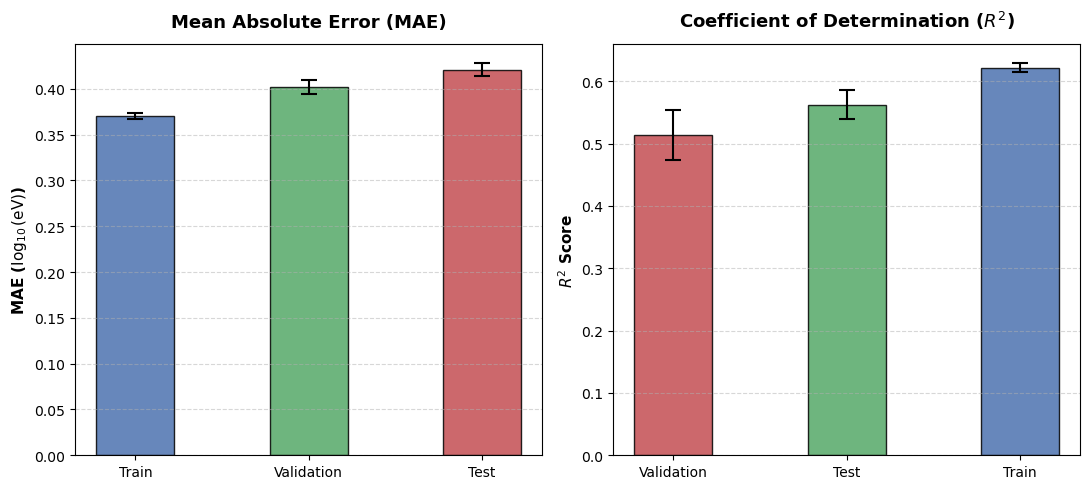

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
file_path = "../Results/741_krr_stratified_both_cv_6_feat_threshold_results.csv"

def plot_cross_validation_results(file_path: str, output_image_path: str):
    # 1. Load the cross-validation results CSV file
    df = pd.read_csv(file_path)
    
    # 2. Extract the summary rows ('Mean' and 'Std')
    mean_row = df[df['Fold'] == 'Mean'].iloc[0]
    std_row = df[df['Fold'] == 'Std'].iloc[0]
    
    # Define our dataset splits
    categories = ['Train', 'Validation', 'Test']
    
    # Extract Mean and Std for MAE
    mae_means = [float(mean_row['Train_MAE']), float(mean_row['Val_MAE']), float(mean_row['Test_MAE'])]
    mae_stds = [float(std_row['Train_MAE']), float(std_row['Val_MAE']), float(std_row['Test_MAE'])]
    
    # Extract Mean and Std for R2
    r2_means = [float(mean_row['Train_R2']), float(mean_row['Val_R2']), float(mean_row['Test_R2'])]
    r2_stds = [float(std_row['Train_R2']), float(std_row['Val_R2']), float(std_row['Test_R2'])]
    
    # 3. Sort the data by mean values to ensure clean presentation
    # MAE Data (Ascending order of means)
    mae_data = sorted(zip(categories, mae_means, mae_stds), key=lambda x: x[1])
    mae_cats, mae_m, mae_s = zip(*mae_data)
    
    # R2 Data (Ascending order of means)
    r2_data = sorted(zip(categories, r2_means, r2_stds), key=lambda x: x[1])
    r2_cats, r2_m, r2_s = zip(*r2_data)
    
    # 4. Initialize a 1x2 side-by-side subplot panel
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
    
    # Design color palettes
    colors_mae = ['#4C72B0', '#55A868', '#C44E52']
    colors_r2 = ['#C44E52', '#55A868', '#4C72B0']
    
    # --- Left Plot: Mean Absolute Error (MAE) ---
    # FIXED: 'elinewidth' handles error bar thickness correctly here
    ax1.bar(mae_cats, mae_m, yerr=mae_s, capsize=6, color=colors_mae, 
            edgecolor='black', alpha=0.85, width=0.45, 
            error_kw={'elinewidth': 1.5, 'capthick': 1.5})
    ax1.set_title('Mean Absolute Error (MAE)', fontsize=13, fontweight='bold', pad=12)
    ax1.set_ylabel('MAE ($\log_{10}(\mathrm{eV})$)', fontsize=11, fontweight='semibold')
    ax1.grid(axis='y', linestyle='--', alpha=0.5)
    ax1.tick_params(labelsize=10)
    
    # --- Right Plot: Coefficient of Determination (R²) ---
    # FIXED: 'elinewidth' handles error bar thickness correctly here
    ax2.bar(r2_cats, r2_m, yerr=r2_s, capsize=6, color=colors_r2, 
            edgecolor='black', alpha=0.85, width=0.45, 
            error_kw={'elinewidth': 1.5, 'capthick': 1.5})
    ax2.set_title('Coefficient of Determination ($R^2$)', fontsize=13, fontweight='bold', pad=12)
    ax2.set_ylabel('$R^2$ Score', fontsize=11, fontweight='semibold')
    ax2.grid(axis='y', linestyle='--', alpha=0.5)
    ax2.tick_params(labelsize=10)
    
    # 5. Fine-tune layout properties to prevent truncation and clipping
    plt.tight_layout()
    
    # 6. Save image directly to file system
    plt.savefig(output_image_path, dpi=300)
    print(f"Plot successfully saved as '{output_image_path}'")

# Execute script call
if __name__ == "__main__":
    file_path = "../Results/741_krr_stratified_both_cv_6_feat_threshold_results.csv"
    output_image = "Image/741_6feat_krr_metrics_variance.png"
    plot_cross_validation_results(file_path, output_image)